In [ ]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"add-your-project-path-here\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [2]:
from utils.data_loader import DataLoader
from utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import keras
import tensorflow as tf
import keras
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [3]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [4]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [5]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")

def custom_callback( monitor, mode, patience, filepath):
    """ early stopping and model checkpoint callbacks for training """
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc

def plot_regression_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # MAE
    axes[0].plot(history.history['mae'], label='Train MAE')
    axes[0].plot(history.history['val_mae'], label='Val MAE')
    axes[0].set(title='MAE', xlabel='Epoch', ylabel='MAE')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss + RMSE
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(history.history['rmse'], '--', label='Train RMSE')
        axes[1].plot(history.history['val_rmse'], '--', label='Val RMSE')
    axes[1].set(title='Loss & RMSE', xlabel='Epoch', ylabel='Value')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # R²
    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R²')
        axes[2].plot(history.history['val_r2'], label='Val R²')
        axes[2].set(title='R² Score', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda k: f"{history.history[k][best]:.4f}" if k in history.history else "NA"

    print(f"\nBest Epoch: {best+1}")
    print("-" * 40)

    print(f"MAE   → Train: {get('mae')} | Val: {get('val_mae')}")
    print(f"RMSE  → Train: {get('rmse')} | Val: {get('val_rmse')}")
    print(f"R²    → Train: {get('r2')} | Val: {get('val_r2')}")
    print(f"Loss  → Train: {get('loss')} | Val: {get('val_loss')}")

    # optional
    if 'mape' in history.history:
        print(f"MAPE  → Train: {get('mape')} | Val: {get('val_mape')}")
        

### Data Acquisition

In [6]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [7]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [8]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [9]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

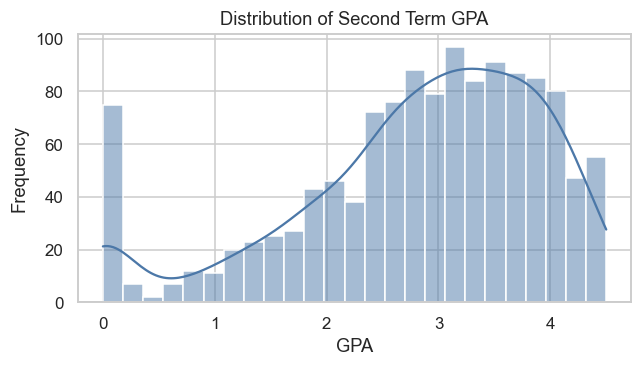

In [10]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [12]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [13]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [14]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="random_forest")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()

C:\Vivek\Soft\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [15]:
# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_term_gpa_missing,high_school_average_mark_missing,...,funding_4,funding_5,funding_8,funding_9,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3
78,0.485630,1,0,0,3,0.909471,0.455197,7,0,1,...,True,False,False,False,True,False,False,True,False,False
353,-0.762264,0,0,1,2,0.306190,0.045668,7,0,0,...,False,False,False,False,False,True,False,False,True,False
1354,0.366174,1,0,0,4,1.024018,1.329298,8,0,1,...,True,False,False,False,True,False,False,False,True,False
510,1.165193,0,1,1,4,-0.648370,1.576470,9,0,0,...,False,False,False,False,False,True,False,False,True,False
338,-0.470226,0,1,1,2,-0.171090,-0.708310,9,0,0,...,False,False,False,False,False,True,False,True,False,False


### Model Construction

In [16]:
# Construct the regression model
model = keras.Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)  # regression output (linear)
])

model.summary()

C:\Vivek\Soft\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,489 (60.50 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
# Model compilation
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae", "mape", RMSEMetric(name="rmse"), R2Metric(name="r2")]
)

In [18]:
# Calling custom callbacks
early_stopping, model_checkpoint = custom_callback(monitor="val_loss", mode="min", patience=20, filepath=project_path/"second_term_gpa_regression/models/regression_model.keras")

# Model training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/200
23/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3873 - mae: 1.3133 - mape: 47769198.9681 - r2: -37.8350 - rmse: 1.5366
Epoch 1: val_loss improved from None to 0.18561, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 1.4914 - mae: 1.0014 - mape: 47353384.0000 - r2: -21.6412 - rmse: 1.2212 - val_loss: 0.1856 - val_mae: 0.3820 - val_mape: 7611849.5000 - val_r2: -2.1804 - val_rmse: 0.4308
Epoch 2/200
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5379 - mae: 0.5773 - mape: 27563680.9600 - r2: -7.9151 - rmse: 0.7308
Epoch 2: val_loss improved from 0.18561 to 0.06989, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Pr

### Training History

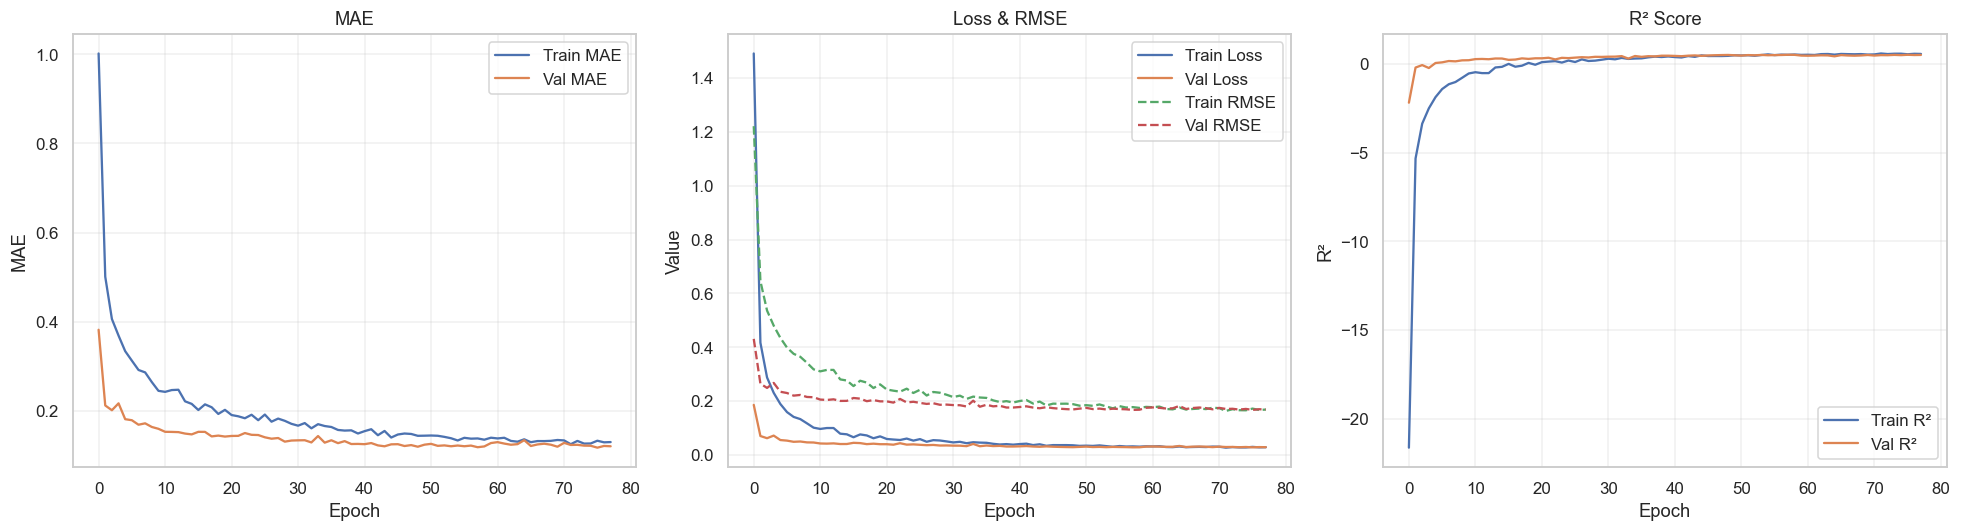


Best Epoch: 58
----------------------------------------
MAE   → Train: 0.1383 | Val: 0.1186
RMSE  → Train: 0.1773 | Val: 0.1669
R²    → Train: 0.5229 | Val: 0.5225
Loss  → Train: 0.0314 | Val: 0.0279
MAPE  → Train: 13105290.0000 | Val: 15620339.0000


In [19]:
# Plot training history
plot_regression_history(history)

In [20]:
# Evaluate on test set
from sklearn.metrics import mean_squared_error, r2_score

test_loss, test_mae, test_mape, _, _ = model.evaluate(X_test, y_test, verbose=0)
y_pred_scaled = model.predict(X_test, verbose=0).ravel()
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
test_r2 = r2_score(y_test, y_pred_scaled)
print(f"\nTest Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f} | Test MAPE: {test_mape:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")


Test Loss: 0.0207 | Test MAE: 0.1090 | Test MAPE: 8956079.0000 | Test RMSE: 0.1439 | Test R²: 0.6197


### Predictions

In [22]:
# Predictions vs actuals on test set
test_df = pd.DataFrame({
    "Actual GPA": scaler.inverse_transform(y_test.reshape(-1, 1)).flatten(),
    "Predicted GPA": scaler.inverse_transform(model.predict(X_test).reshape(-1, 1)).flatten(),
    "MAE": np.abs(y_test - model.predict(X_test).ravel()),
    "MSE": (y_test - model.predict(X_test).ravel())**2
})
display(test_df)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Actual GPA,Predicted GPA,MAE,MSE
0,3.886364,3.536801,0.077681,0.006034
1,2.222222,2.789235,0.126003,0.015877
2,3.100000,3.189249,0.019833,0.000393
3,2.235294,2.733478,0.110707,0.012256
4,2.975000,4.104545,0.251010,0.063006
...,...,...,...,...
251,3.604167,4.332138,0.161771,0.026170
252,0.250000,1.650377,0.311195,0.096842
253,3.500000,3.901590,0.089242,0.007964
254,3.440000,3.361568,0.017429,0.000304


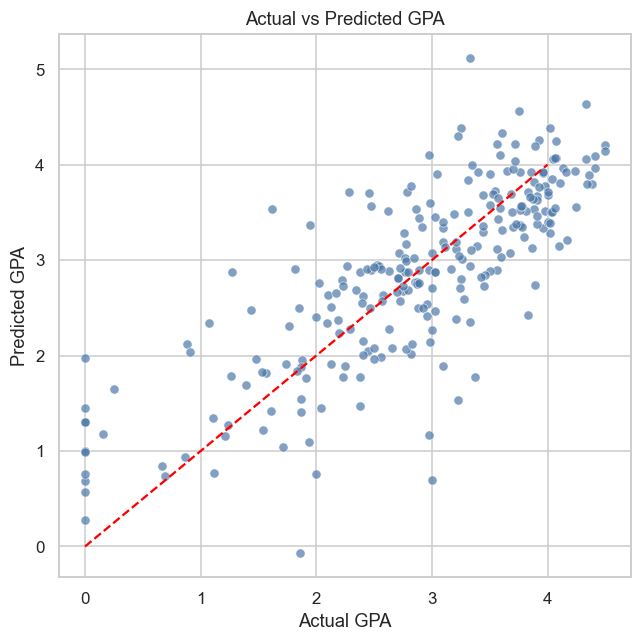

In [23]:
# Scatter plot of actual vs predicted GPA
plt.figure(figsize=(6,6))
sns.scatterplot(x="Actual GPA", y="Predicted GPA", data=test_df, color="#4c78a8", alpha=0.7)
plt.plot([0, 4], [0, 4], color="red", linestyle="--")  # Line for perfect predictions
plt.title("Actual vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.tight_layout()
plt.show()

### Keras Tuner

In [24]:
def build_tuner_model(hp):
    input_dim = X_train.shape[1]
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])

    for i in range(hp.Int("num_layers", 1, 5)):
        units = hp.Choice(f"neurons_{i}", [64, 128, 256, 512, 1024])
        activation = hp.Choice(f"act_{i}", ["relu", "tanh", "elu"])
        dropout_rate = hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.1)

        model.add(Dense(units, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))   # regression output

    opt = hp.Choice("optimizer", ["adam", "sgd", "rmsprop"])
    lr = hp.Choice("learning_rate", [0.0001, 0.0005, 0.001, 0.005, 0.01])

    if opt == "adam":
        optimizer = Adam(learning_rate=lr)
    elif opt == "sgd":
        optimizer = SGD(learning_rate=lr, momentum=0.9)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae", "mape", RMSEMetric(name="rmse"), R2Metric(name="r2")]
    )
    return model

def show_best_hyperparameters(hyperparameters):
    rows = [{"hyperparameter": k, "value": v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

### Hyberband Search

In [25]:
import shutil
import time
from keras_tuner import Hyperband
from tensorflow.keras.callbacks import EarlyStopping

tuner_dir = project_path / "second_term_gpa_regression" / "tuner" / "student_tuner"

if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print("KERAS TUNER SEARCH")

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective="val_loss",
    max_epochs=40,
    factor=3,
    directory=project_path / "second_term_gpa_regression" / "tuner" / "student_tuner",
    project_name="student_tuner",
    seed=42,
    overwrite=True
)

search_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode="min"
)

start_time = time.time()

hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    callbacks=[search_stop],
    verbose=1
)

search_time = time.time() - start_time

print(f"Search completed in {search_time / 60:.1f} minutes")
hyperband_tuner.results_summary(num_trials=10)

best_hps_list = hyperband_tuner.get_best_hyperparameters(1)
if not best_hps_list:
    raise RuntimeError("Hyperband completed without any successful trials. Check tuner logs above.")

best_hps = best_hps_list[0]
print("BEST HYPERPARAMETERS")
show_best_hyperparameters(best_hps)

Trial 85 Complete [00h 00m 12s]
val_loss: 0.02547496184706688

Best val_loss So Far: 0.022159431129693985
Total elapsed time: 00h 11m 57s
Search completed in 12.0 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0080 summary
Hyperparameters:
num_layers: 1
neurons_0: 128
act_0: elu
dropout_0: 0.2
optimizer: adam
learning_rate: 0.01
neurons_1: 512
act_1: relu
dropout_1: 0.1
neurons_2: 64
act_2: elu
dropout_2: 0.2
neurons_3: 64
act_3: relu
dropout_3: 0.30000000000000004
neurons_4: 64
act_4: relu
dropout_4: 0.2
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.022159431129693985

Trial 0046 summary
Hyperparameters:
num_layers: 1
neurons_0: 64
act_0: relu
dropout_0: 0.4
optimizer: adam
learning_rate: 0.005
neurons_1: 512
act_1: tanh
dropout_1: 0.2
neuron

,hyperparameter,value
0,num_layers,1
1,neurons_0,128
2,act_0,elu
3,dropout_0,0.2
4,optimizer,adam
5,learning_rate,0.01
6,neurons_1,512
7,act_1,relu
8,dropout_1,0.1
9,neurons_2,64


### Export Trials as CSV

In [ ]:
all_trials = list(hyperband_tuner.oracle.trials.values())

results_df = pd.DataFrame([
    {
        "Loss (MSE)": t.metrics.metrics["loss"].get_best_value()
            if "loss" in t.metrics.metrics else None,

        "Val_Loss (MSE)": t.metrics.metrics["val_loss"].get_best_value()
            if "val_loss" in t.metrics.metrics else None,

        "MAE": t.metrics.metrics["mae"].get_best_value()
            if "mae" in t.metrics.metrics else None,
            
        "Val_MAE": t.metrics.metrics["val_mae"].get_best_value()
            if "val_mae" in t.metrics.metrics else None,

        "MAPE": t.metrics.metrics["mape"].get_best_value()
            if "mape" in t.metrics.metrics else None,

        "Val_MAPE": t.metrics.metrics["val_mape"].get_best_value()
            if "val_mape" in t.metrics.metrics else None,

        "RMSE": t.metrics.metrics["rmse"].get_best_value()
            if "rmse" in t.metrics.metrics else None,

        "Val_RMSE": t.metrics.metrics["val_rmse"].get_best_value()
            if "val_rmse" in t.metrics.metrics else None,

        "R2": t.metrics.metrics["r2"].get_best_value()
            if "r2" in t.metrics.metrics else None,

        "Val_R2": t.metrics.metrics["val_r2"].get_best_value()
            if "val_r2" in t.metrics.metrics else None,

        **t.hyperparameters.values
    }
    for t in all_trials
]).sort_values("Val_Loss (MSE)", ascending=True)

results_df.insert(0, "ID", range(1, len(results_df) + 1))

results_df.to_csv(
    project_path / "second_term_gpa_regression" / "trial_results" /"keras_tuner_results_regression_rf.csv",
    index=False
)

C:\Vivek\Soft\anaconda3\Lib\site-packages\keras_tuner\src\engine\metrics_tracking.py:111: RuntimeWarning: All-NaN axis encountered
  np.nanmin(values) if self.direction == "min" else np.nanmax(values)


In [29]:
print("TOP 20 BEST TRIALS (by Validation Loss)")
print(results_df.head(20).to_string(index=False))

TOP 20 BEST TRIALS (by Validation Loss)
 ID  Loss (MSE)  Val_Loss (MSE)      MAE  Val_MAE       MAPE   Val_MAPE     RMSE  Val_RMSE        R2   Val_R2  num_layers  neurons_0 act_0  dropout_0 optimizer  learning_rate  tuner/epochs  tuner/initial_epoch  tuner/bracket  tuner/round  neurons_1 act_1  dropout_1  neurons_2 act_2  dropout_2  neurons_3 act_3  dropout_3  neurons_4 act_4  dropout_4 tuner/trial_id
  1    0.031299        0.022159 0.135289 0.104662 16447720.0 13054899.0 0.176916  0.148860  0.524841 0.620300           1        128   elu        0.2      adam         0.0100            40                    0              0            0        512  relu        0.1         64   elu        0.2         64  relu        0.3       64.0  relu        0.2            NaN
  2    0.032031        0.022373 0.138956 0.103093 17201524.0 15304660.0 0.178973  0.149576  0.513727 0.616642           1         64  relu        0.4      adam         0.0050            14                    5              3      

In [33]:
# best model from the search high accuracy and low loss on validation set
overall_best_trial = hyperband_tuner.get_best_hyperparameters(3)[0]
best_model = hyperband_tuner.hypermodel.build(overall_best_trial)
best_model.summary()

# observe training with early stopping and model checkpointing
early_stopping, checkpoint = custom_callback(monitor="val_loss", mode="min", patience=20, filepath=project_path/"second_term_gpa_regression/models/best_regression_model_rf.keras")

history = best_model.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint],
    verbose=1,
)

print("Training completed.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/200
16/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4952 - mae: 0.9223 - mape: 48944076.9375 - r2: -21.9513 - rmse: 1.2134
Epoch 1: val_loss improved from None to 0.20165, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.8292 - mae: 0.6566 - mape: 49167120.0000 - r2: -11.5875 - rmse: 0.9106 - val_loss: 0.2017 - val_mae: 0.4031 - val_mape: 3908586.5000 - val_r2: -2.4553 - val_rmse: 0.4491
Epoch 2/200
15/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2833 - mae: 0.3883 - mape: 30551840.0000 - r2: -3.2647 - rmse: 0.5310 
Epoch 2: val_loss improved from 0.20165 to 0.05348, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networ

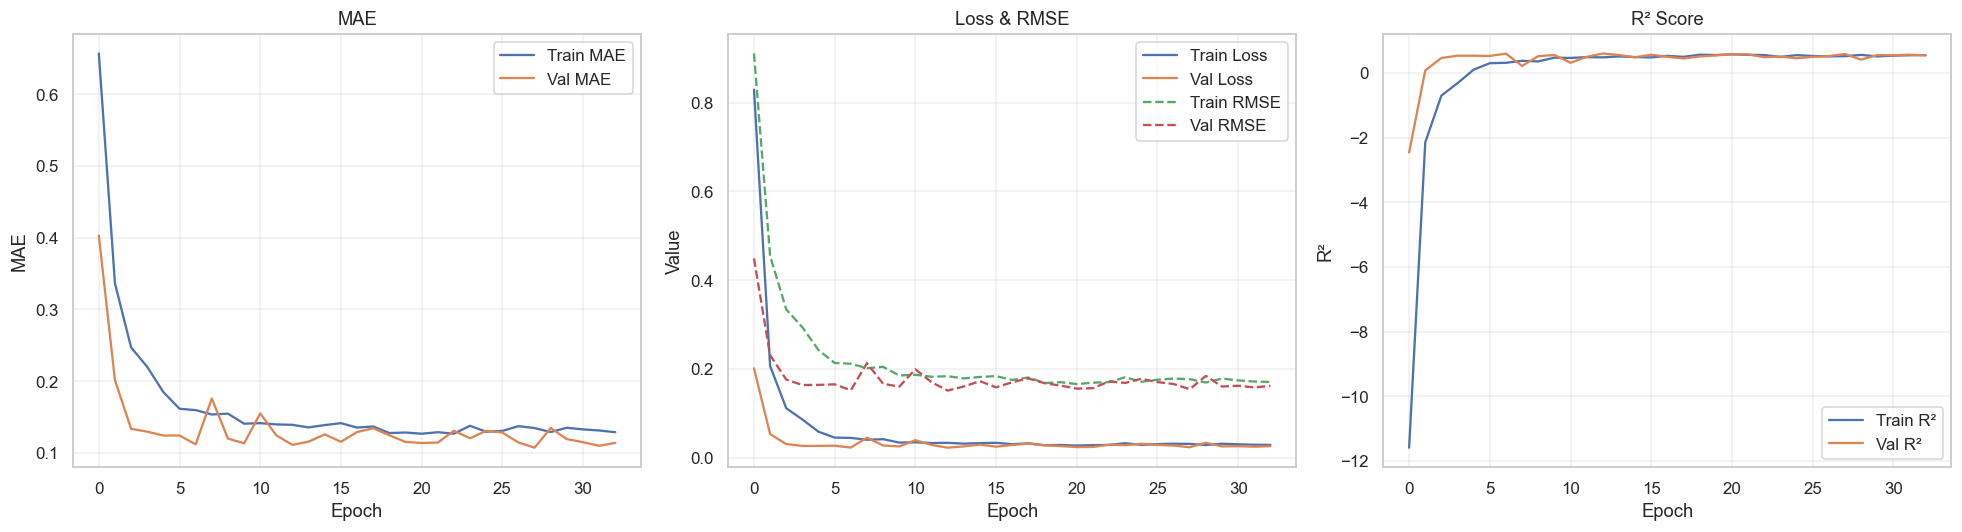


Best Epoch: 13
----------------------------------------
MAE   → Train: 0.1392 | Val: 0.1113
RMSE  → Train: 0.1838 | Val: 0.1515
R²    → Train: 0.4870 | Val: 0.6069
Loss  → Train: 0.0338 | Val: 0.0229
MAPE  → Train: 15208215.0000 | Val: 13459491.0000


In [34]:
# visualize training history of the best model
plot_regression_history(history)

In [36]:
# Evaluate the best model on the test set
test_loss, test_mae, test_mape, test_rmse,test_r2 = best_model.evaluate(X_test, y_test)
print(f"\nBest Model Test Loss: {test_loss:.4f} | Test MAE: {test_mae:.4f} | Test MAPE: {test_mape:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0183 - mae: 0.1076 - mape: 12402598.0000 - r2: 0.6649 - rmse: 0.1351

Best Model Test Loss: 0.0183 | Test MAE: 0.1076 | Test MAPE: 12402598.0000 | Test RMSE: 0.1351 | Test R²: 0.6649


In [38]:
#Predictions vs actuals on test set
test_df = pd.DataFrame({
    "Actual GPA": scaler.inverse_transform(y_test.reshape(-1, 1)).flatten(),
    "Predicted GPA": scaler.inverse_transform(best_model.predict(X_test).reshape(-1, 1)).flatten(),
    "MAE": np.abs(y_test - best_model.predict(X_test).ravel()),
    "MSE": (y_test - best_model.predict(X_test).ravel())**2
})

display(test_df)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,Actual GPA,Predicted GPA,MAE,MSE
0,3.886364,3.167076,0.159842,0.025549
1,2.222222,2.598027,0.083512,0.006974
2,3.100000,2.979930,0.026682,0.000712
3,2.235294,2.753994,0.115267,0.013286
4,2.975000,3.304382,0.073196,0.005358
...,...,...,...,...
251,3.604167,3.478492,0.027928,0.000780
252,0.250000,2.248324,0.444072,0.197200
253,3.500000,3.452794,0.010490,0.000110
254,3.440000,3.095130,0.076638,0.005873


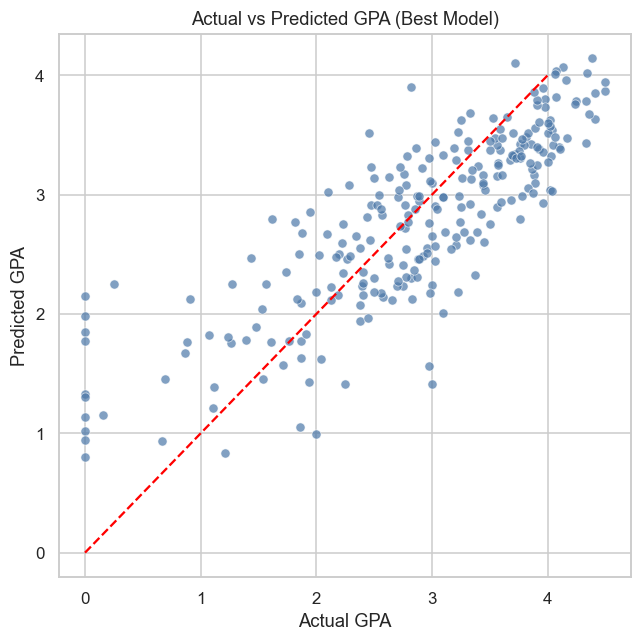

In [39]:
# Scatter plot of actual vs predicted GPA for the best model
plt.figure(figsize=(6,6))
sns.scatterplot(x="Actual GPA", y="Predicted GPA", data=test_df, color="#4c78a8", alpha=0.7)
plt.plot([0, 4], [0, 4], color="red", linestyle="--")  # Line for perfect predictions
plt.title("Actual vs Predicted GPA (Best Model)")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.tight_layout()
plt.show()